In [180]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="white", context="talk")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

In [181]:
df=pd.read_csv(r"netflix_titles.csv")

In [182]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [184]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [185]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [186]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [187]:
df.duplicated().sum()

np.int64(0)

## **Drop the unrequired columns**

In [188]:
df.drop(columns=['show_id'], inplace=True)

# **Dealing With Null** **Values**


In [189]:
df.isnull().sum()

,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
listed_in,0


In [190]:
df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown'
}, inplace=True)

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])


df['duration'] = df['duration'].fillna(df['duration'].mode()[0])


df.dropna(subset=['date_added'], inplace=True)

In [191]:
df.isnull().sum()

,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [192]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8797 non-null   object        
 1   title         8797 non-null   object        
 2   director      8797 non-null   object        
 3   cast          8797 non-null   object        
 4   country       8797 non-null   object        
 5   date_added    8709 non-null   datetime64[ns]
 6   release_year  8797 non-null   int64         
 7   rating        8797 non-null   object        
 8   duration      8797 non-null   object        
 9   listed_in     8797 non-null   object        
 10  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 824.7+ KB


In [194]:
print(df.shape)


# Genre analysis dataframe
df_genre = df.copy()

df_genre['listed_in'] = df_genre['listed_in'].str.split(', ')

df_genre = df_genre.explode('listed_in')

print(df_genre.shape)

(8797, 11)
(19303, 11)


## **Feature Engineering**

In [195]:
df['year_added'] = df['date_added'].dt.year

df['month_added'] = df['date_added'].dt.month_name()

## ***Data Visualization With EDA***

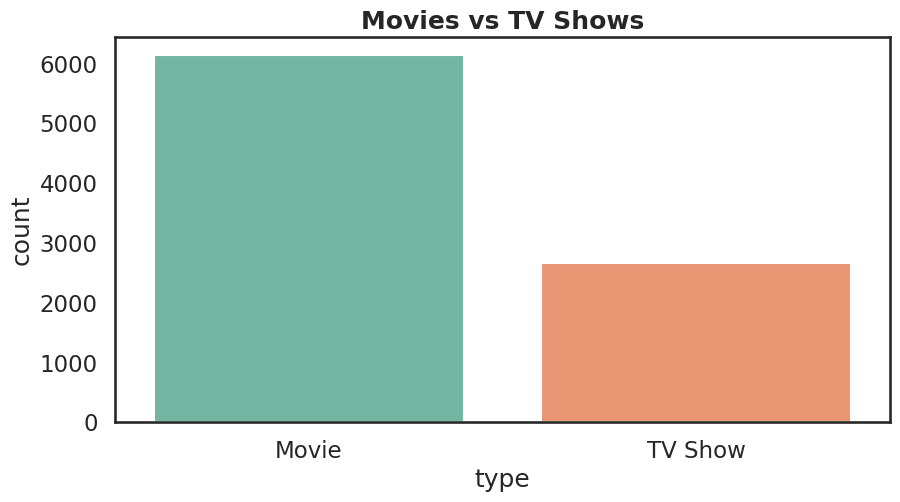

In [214]:
sns.countplot(data=df, x='type', palette='Set2')

plt.title("Movies vs TV Shows")

plt.show()

Content Ratings


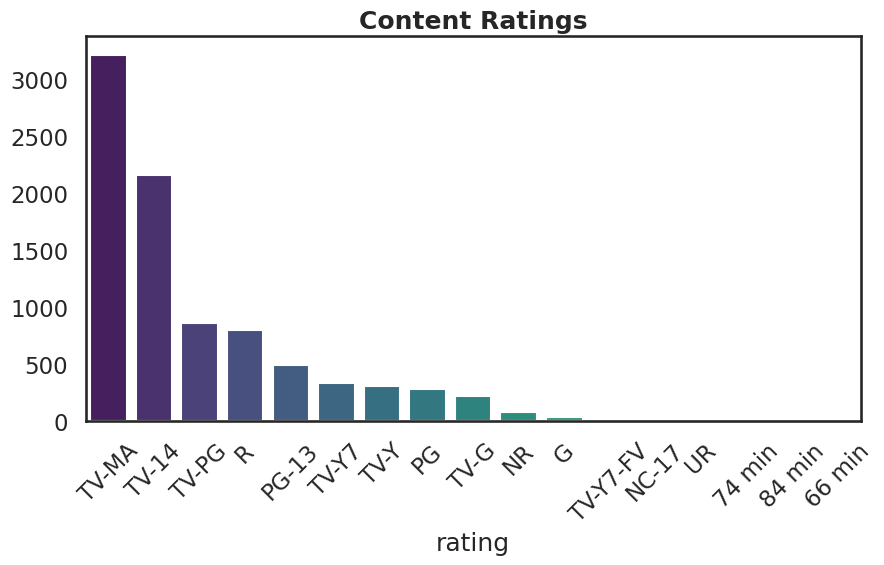

In [215]:
print("Content Ratings")
rating_count = df['rating'].value_counts()

sns.barplot(
    x=rating_count.index,
    y=rating_count.values,
    palette='viridis'
)
plt.title("Content Ratings")
plt.xticks(rotation=45)

plt.show()

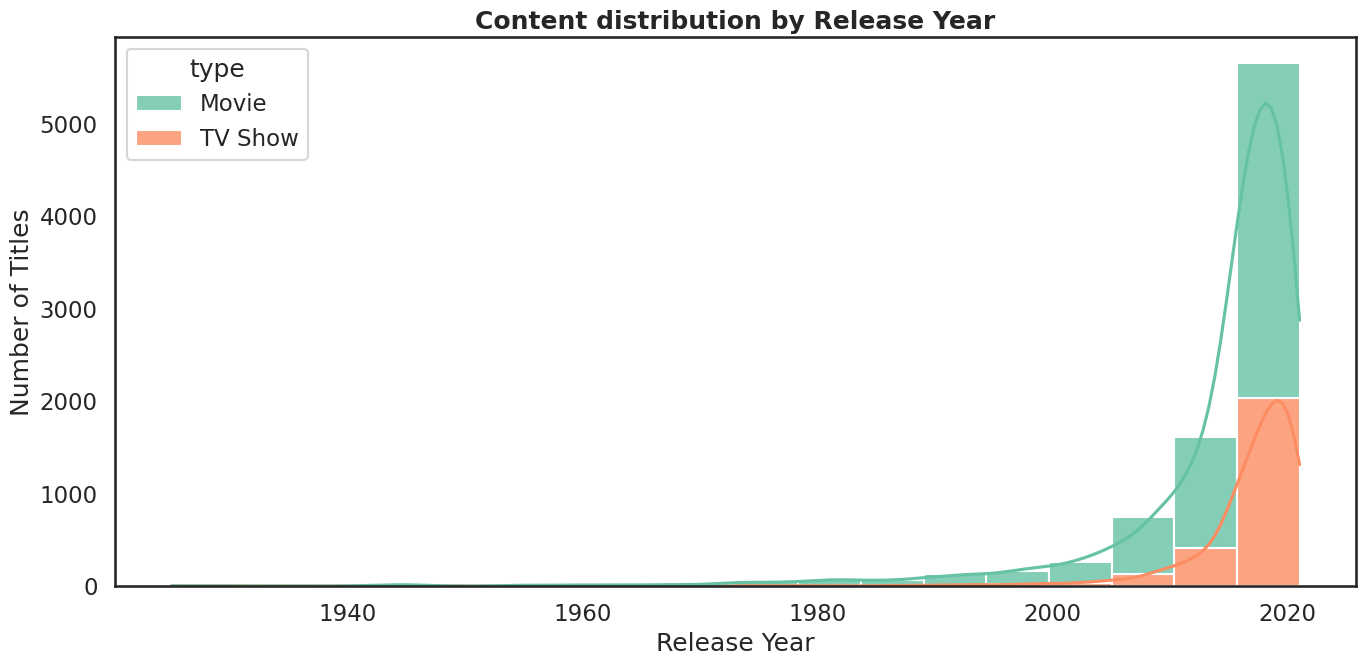

In [217]:

plt.figure(figsize=(14, 7))
sns.histplot(df,x= 'release_year', bins=18, kde=True, hue='type',multiple='stack',palette='Set2',alpha=0.8)
plt.title('Content distribution by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

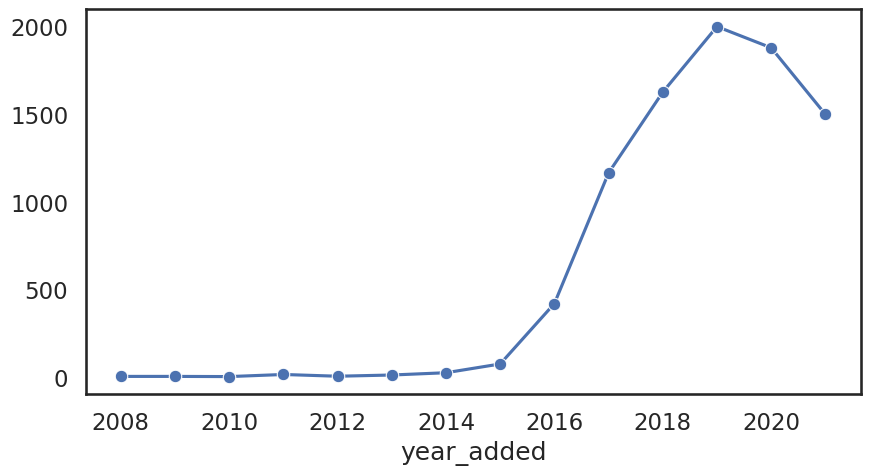

In [199]:
year_added = df['year_added'].value_counts().sort_index()

sns.lineplot(
    x=year_added.index,
    y=year_added.values,
    marker='o'
)

plt.show()

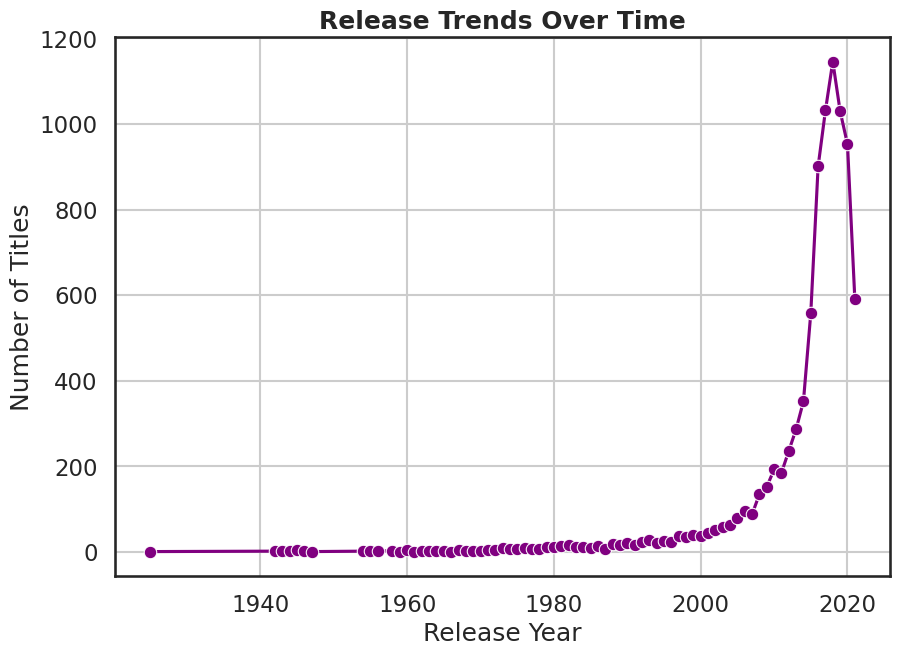

In [200]:
release_trends = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 7))
sns.lineplot(x=release_trends.index, y=release_trends.values,marker='o',color='purple')
plt.grid(True)
plt.title('Release Trends Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

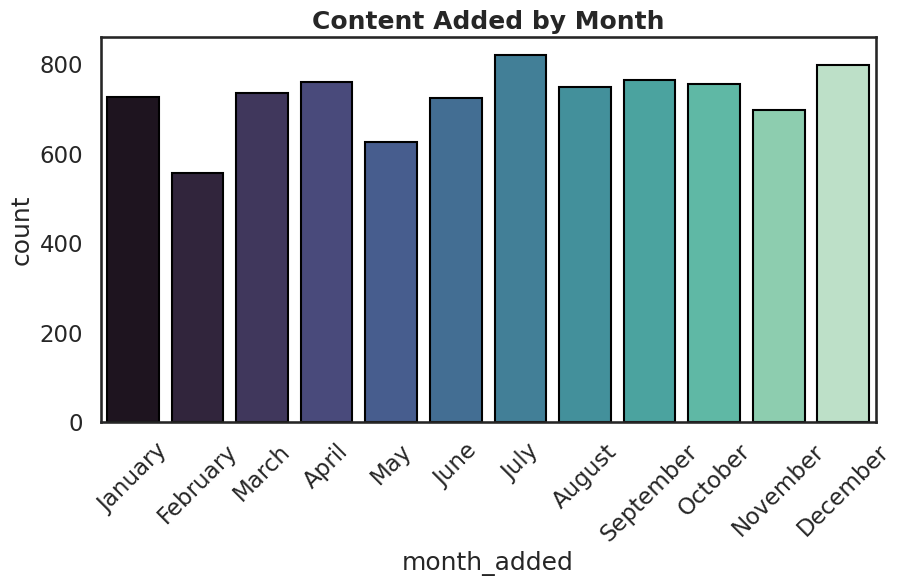

In [218]:
month_order = [
'January','February','March','April',
'May','June','July','August',
'September','October','November','December'
]

sns.countplot(
    data=df,
    x='month_added',
    order=month_order,palette='mako', edgecolor = 'black'
)

plt.xticks(rotation=45)
plt.title("Content Added by Month")
plt.show()

In [202]:
country_df = df.copy()

country_df['country'] = country_df['country'].str.split(', ')

country_df = country_df.explode('country')

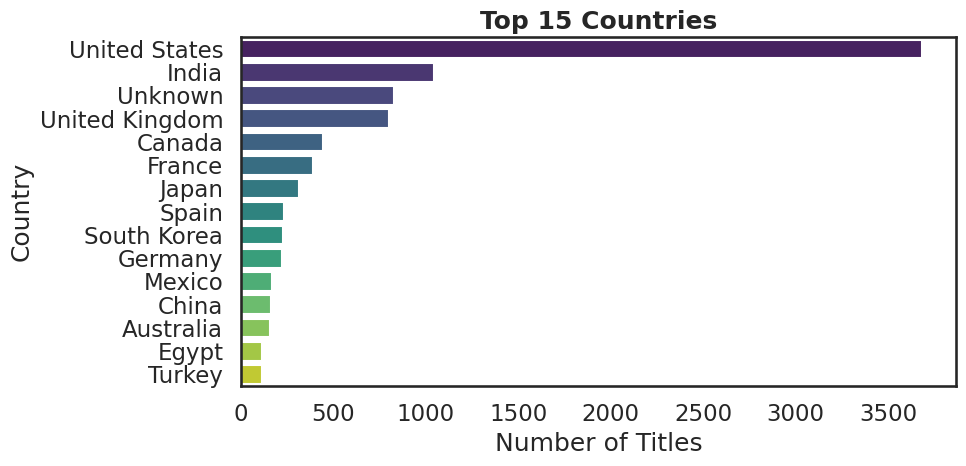

In [219]:
top_country = country_df['country'].value_counts().head(15)

sns.barplot(
    x=top_country.values,
    y=top_country.index,palette = "viridis"
)
plt.title('Top 15 Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [204]:
df_genre = df.copy()

df_genre['listed_in'] = df_genre['listed_in'].str.split(', ')

df_genre = df_genre.explode('listed_in')

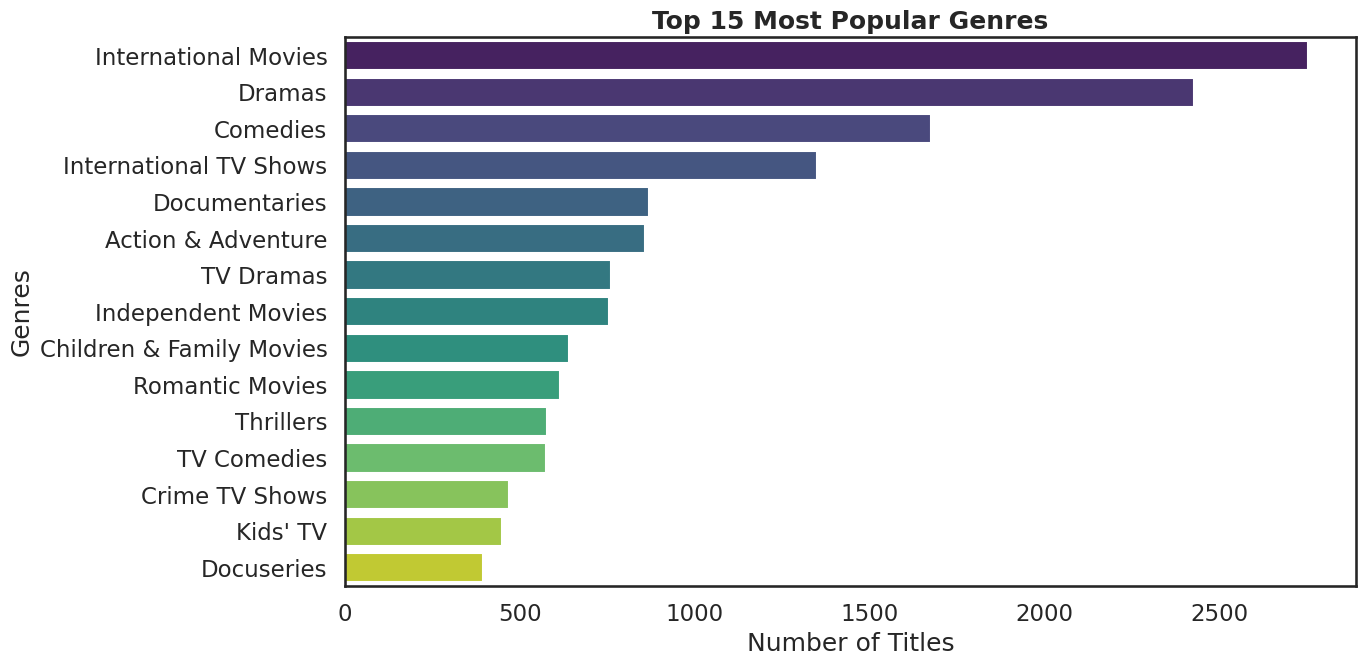

In [205]:
top_genres = df_genre['listed_in'].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title('Top 15 Most Popular Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genres')
plt.tight_layout()
plt.show()

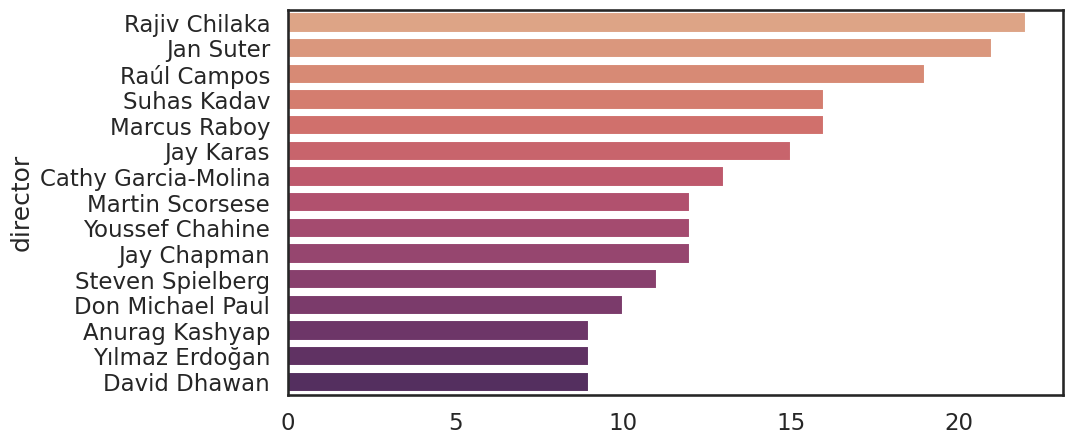

In [206]:
director_df = df.copy()

director_df['director'] = director_df['director'].str.split(', ')

director_df = director_df.explode('director')

top_directors = (
    director_df[
        director_df['director']!='Unknown'
    ]
    ['director']
    .value_counts()
    .head(15)
)

sns.barplot(
    x=top_directors.values,
    y=top_directors.index, palette='flare'
)

plt.show()

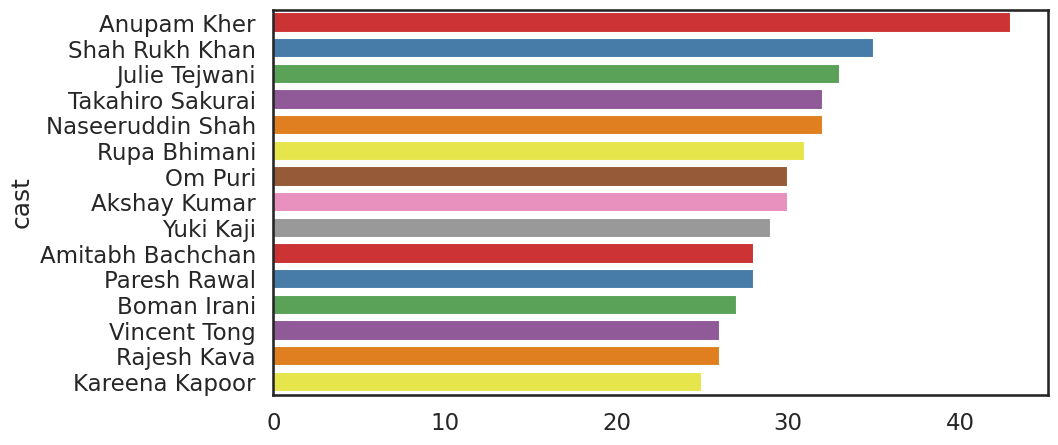

In [207]:
cast_df = df.copy()

cast_df['cast'] = cast_df['cast'].str.split(', ')

cast_df = cast_df.explode('cast')

top_actors = (
    cast_df[
        cast_df['cast']!='Unknown'
    ]
    ['cast']
    .value_counts()
    .head(15)
)

sns.barplot(
    x=top_actors.values,
    y=top_actors.index,palette="Set1"
)

plt.show()

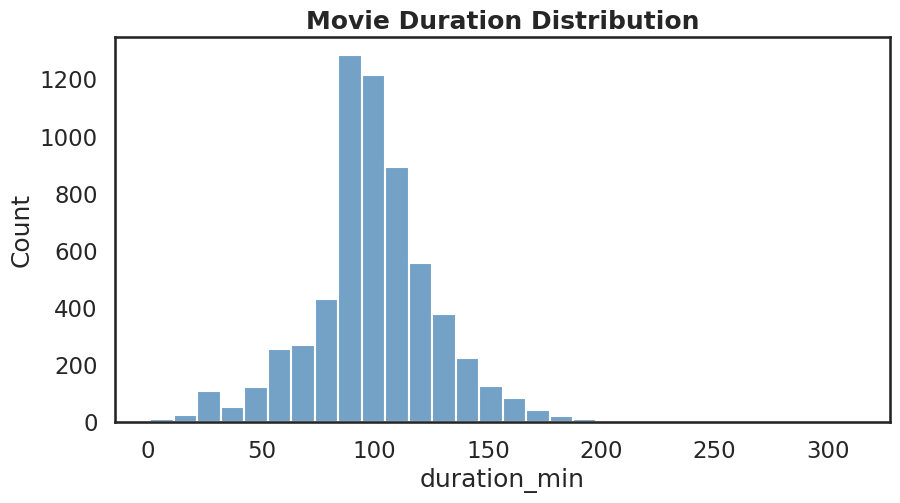

In [221]:
movies = df[df['type']=='Movie'].copy()

movies['duration_min'] = (
    movies['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

sns.histplot(movies['duration_min'], bins=30, color="steelblue")
plt.title("Movie Duration Distribution")

plt.show()

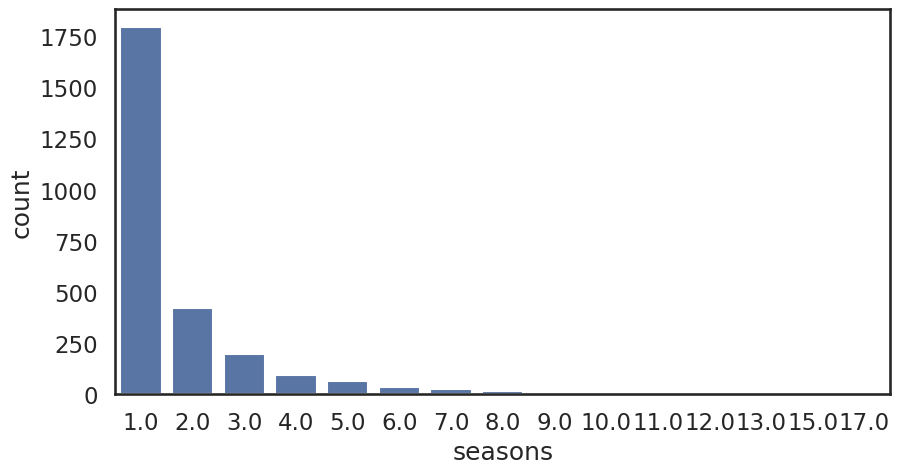

In [209]:
tv = df[df['type']=='TV Show'].copy()

tv['seasons'] = (
    tv['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

sns.countplot(
    x='seasons',
    data=tv
)

plt.show()

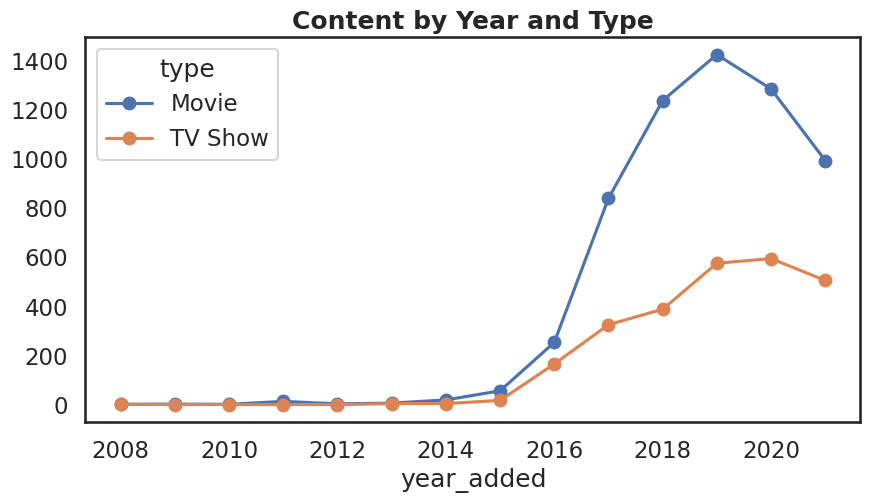

In [223]:
type_year = pd.crosstab(
    df['year_added'],
    df['type']
)

type_year.plot(marker='o', figsize=(10,5))
plt.title("Content by Year and Type")

plt.show()

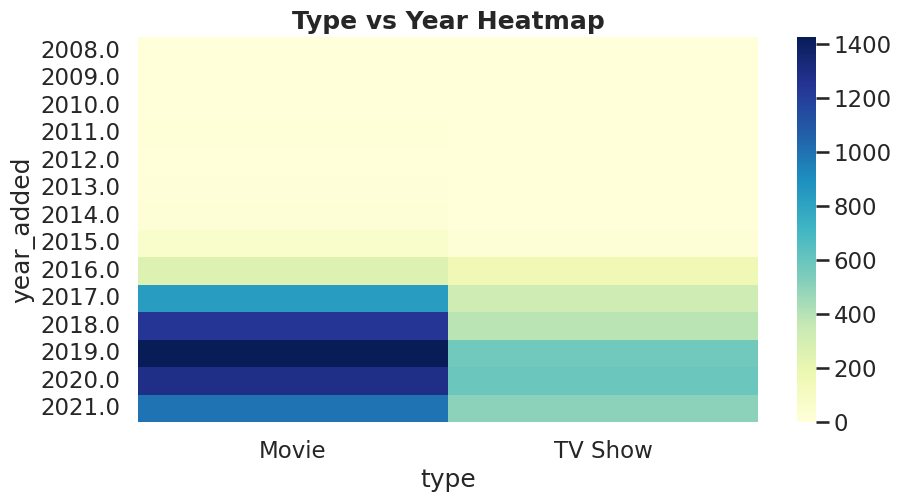

In [222]:
heatmap_data = pd.crosstab(
    df['year_added'],
    df['type']
)


sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False,
    fmt="d"
)
plt.title("Type vs Year Heatmap")
plt.show()

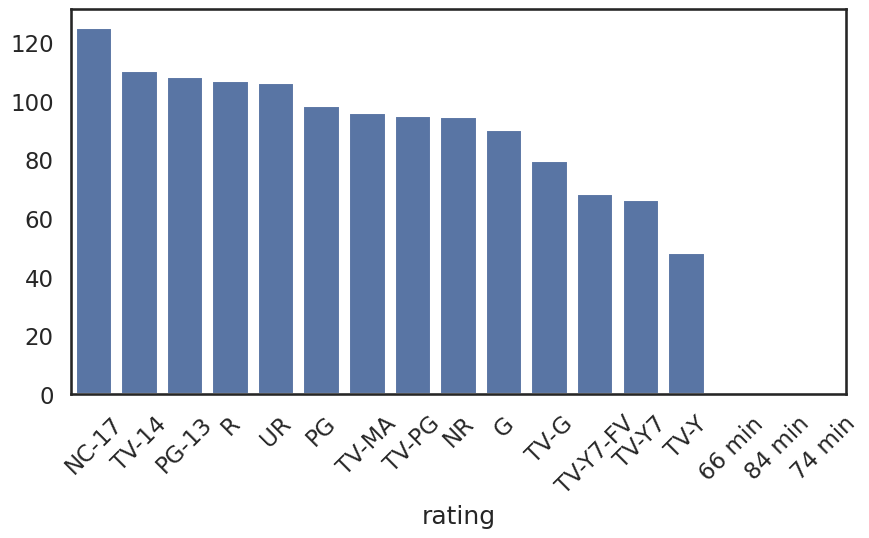

In [212]:
avg_duration = (
    movies.groupby('rating')['duration_min']
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=avg_duration.index,
    y=avg_duration.values
)

plt.xticks(rotation=45)

plt.show()


In [213]:
print("Total Titles :", len(df))

print("Movies :", len(df[df['type']=='Movie']))

print("TV Shows :", len(df[df['type']=='TV Show']))

print("Top Genre :", top_genres.idxmax())

print("Top Country :", top_country.idxmax())

print("Top Director :", top_directors.idxmax())

print("Top Actor :", top_actors.idxmax())

print("Most Common Rating :", df['rating'].mode()[0])

Total Titles : 8797
Movies : 6131
TV Shows : 2666
Top Genre : International Movies
Top Country : United States
Top Director : Rajiv Chilaka
Top Actor : Anupam Kher
Most Common Rating : TV-MA
